In [101]:
import plotly.express as plt

In [102]:
print(dir(plt.data))

['__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'carshare', 'election', 'election_geojson', 'experiment', 'gapminder', 'iris', 'medals_long', 'medals_wide', 'stocks', 'tips', 'wind']


In [103]:
df = plt.data.gapminder()
df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


In [104]:
europe = df[df['continent'] == 'Europe']
europe

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
12,Albania,Europe,1952,55.230,1282697,1601.056136,ALB,8
13,Albania,Europe,1957,59.280,1476505,1942.284244,ALB,8
14,Albania,Europe,1962,64.820,1728137,2312.888958,ALB,8
15,Albania,Europe,1967,66.220,1984060,2760.196931,ALB,8
16,Albania,Europe,1972,67.690,2263554,3313.422188,ALB,8
...,...,...,...,...,...,...,...,...
1603,United Kingdom,Europe,1987,75.007,56981620,21664.787670,GBR,826
1604,United Kingdom,Europe,1992,76.420,57866349,22705.092540,GBR,826
1605,United Kingdom,Europe,1997,77.218,58808266,26074.531360,GBR,826
1606,United Kingdom,Europe,2002,78.471,59912431,29478.999190,GBR,826


In [105]:
europe_2007 = europe[europe['year'] == 2007].sort_values('gdpPercap', ascending=False)
europe_2007

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
1151,Norway,Europe,2007,80.196,4627926,49357.190170,NOR,578
755,Ireland,Europe,2007,78.885,4109086,40675.996350,IRL,372
1487,Switzerland,Europe,2007,81.701,7554661,37506.419070,CHE,756
1091,Netherlands,Europe,2007,79.762,16570613,36797.933320,NLD,528
695,Iceland,Europe,2007,81.757,301931,36180.789190,ISL,352
83,Austria,Europe,2007,79.829,8199783,36126.492700,AUT,40
419,Denmark,Europe,2007,78.332,5468120,35278.418740,DNK,208
1475,Sweden,Europe,2007,80.884,9031088,33859.748350,SWE,752
119,Belgium,Europe,2007,79.441,10392226,33692.605080,BEL,56
527,Finland,Europe,2007,79.313,5238460,33207.084400,FIN,246


In [106]:
fig1 = plt.bar(
    europe_2007,
    x='country',
    y='gdpPercap',
    color='country',
    text='gdpPercap',
    orientation='v',
    title='GDP Per Capita — European Countries (2007)',
    labels={'gdpPercap': 'GDP Per Capita (USD)', 'country': 'Country'},
    template='plotly_dark',
)
 
fig1.update_traces(
    texttemplate='$%{text:.0f}',
    textposition='outside',
)
 
fig1.update_layout(
    xaxis_tickangle=-45,
    showlegend=False,
    bargap=0.2,
)
 
fig1.show()

In [107]:
fig2 = plt.bar(
    europe,
    x='year',
    y='gdpPercap',
    animation_frame='country',          
    animation_group='year',               
    range_y=[0, europe['gdpPercap'].max() * 1.1],
    title='GDP Per Capita Over the Years — Animated by Country',
    labels={'gdpPercap': 'GDP Per Capita (USD)', 'year': 'Year'},
    template='plotly_dark',
)
 
fig2.update_layout(
    bargap=0.3,
)
 
fig2.show()

In [108]:
df = plt.data.election()
 
print(df.head())
print(df.columns.tolist())

                district  Coderre  Bergeron  Joly  total    winner     result  \
0     101-Bois-de-Liesse     2481      1829  3024   7334      Joly  plurality   
1  102-Cap-Saint-Jacques     2525      1163  2675   6363      Joly  plurality   
2   11-Sault-au-Récollet     3348      2770  2532   8650   Coderre  plurality   
3           111-Mile-End     1734      4782  2514   9030  Bergeron   majority   
4         112-DeLorimier     1770      5933  3044  10747  Bergeron   majority   

   district_id  
0          101  
1          102  
2           11  
3          111  
4          112  
['district', 'Coderre', 'Bergeron', 'Joly', 'total', 'winner', 'result', 'district_id']


In [109]:
df_long = df.melt(
    id_vars=['district', 'result'],
    value_vars=['Coderre', 'Joly', 'Bergeron'],
    var_name='candidate',
    value_name='votes'
)

In [110]:
fig1 = plt.histogram(
    df_long,
    x='votes',
    color='candidate',                        
    barmode='overlay',                       
    opacity=0.7,
    nbins=30,
    title='Votes Distribution — Coderre vs Joly vs Bergeron (Overlay)',
    labels={'votes': 'Votes', 'candidate': 'Candidate'},
    template='plotly_dark',
    color_discrete_map={
        'Coderre':  '#378ADD',
        'Joly':     '#1D9E75',
        'Bergeron': '#D85A30',
    }
)
 
fig1.update_layout(bargap=0.1)
fig1.show()

In [111]:
fig2 = plt.histogram(
    df_long,
    x='votes',
    color='candidate',
    barmode='group',            
    nbins=20,
    title='Votes Distribution — Coderre vs Joly vs Bergeron (Grouped)',
    labels={'votes': 'Votes', 'candidate': 'Candidate'},
    template='plotly_dark',
    color_discrete_map={
        'Coderre':  '#378ADD',
        'Joly':     '#1D9E75',
        'Bergeron': '#D85A30',
    }
)
 
fig2.update_layout(bargap=0.1)
fig2.show()

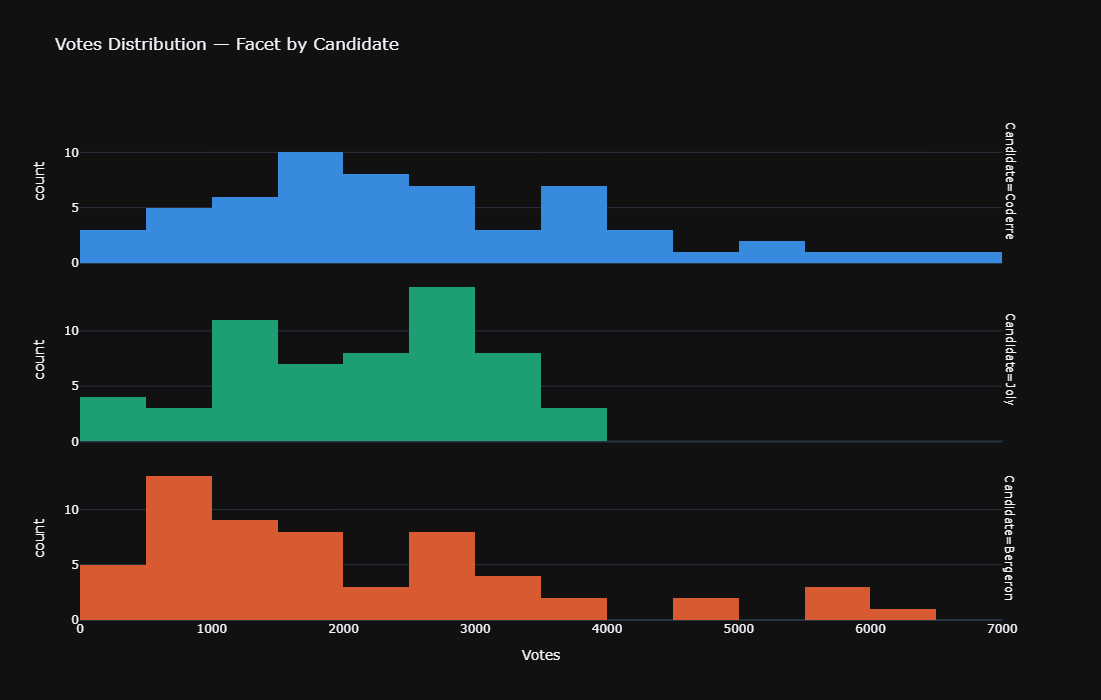

In [112]:
fig3 = plt.histogram(
    df_long,
    x='votes',
    color='candidate',
    facet_row='candidate',                    
    nbins=20,
    title='Votes Distribution — Facet by Candidate',
    labels={'votes': 'Votes', 'candidate': 'Candidate'},
    template='plotly_dark',
    color_discrete_map={
        'Coderre':  '#378ADD',
        'Joly':     '#1D9E75',
        'Bergeron': '#D85A30',
    }
)
 
fig3.update_layout(
    height=700,
    showlegend=False,
)
fig3.show()

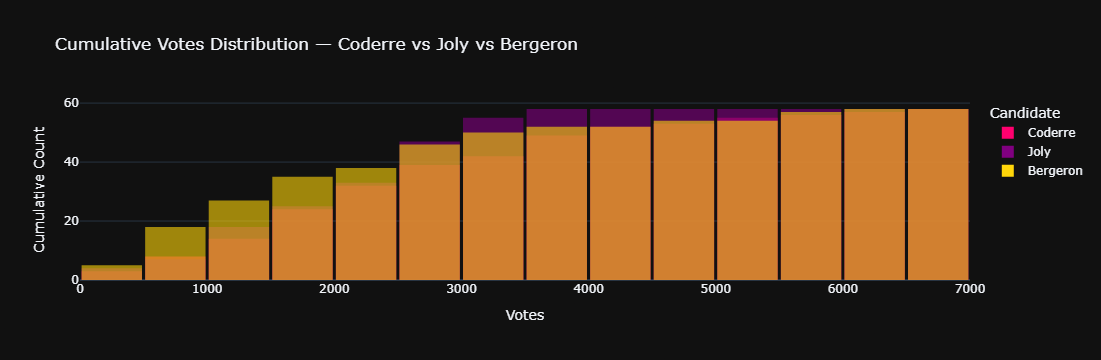

In [113]:
fig4 = plt.histogram(
    df_long,
    x='votes',
    color='candidate',
    barmode='overlay',
    opacity=0.6,
    nbins=30,
    cumulative=True,                          
    title='Cumulative Votes Distribution — Coderre vs Joly vs Bergeron',
    labels={'votes': 'Votes', 'candidate': 'Candidate'},
    template='plotly_dark',
    color_discrete_map={
        'Coderre':  '#FF006E',  
        'Joly':     'purple',   
        'Bergeron': '#FFD60A',  
    }
)
 
fig4.update_layout(
    bargap=0.05,
    yaxis_title='Cumulative Count',
)
fig4.show()

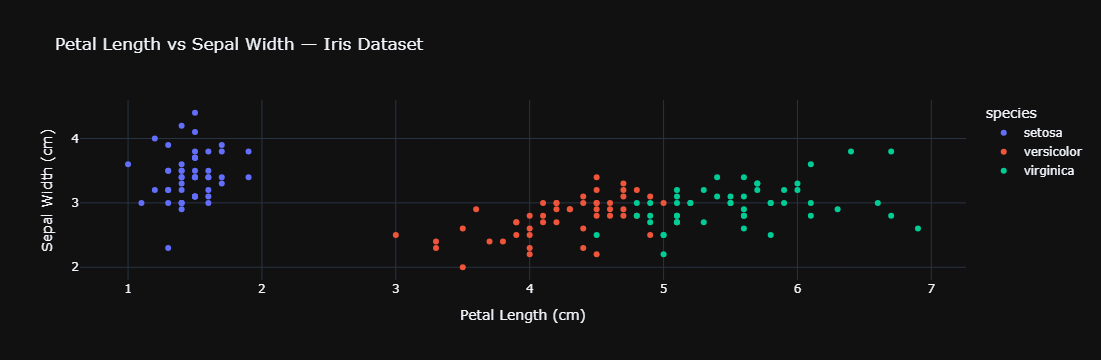

In [114]:
df = plt.data.iris()

fig = plt.scatter(
    df,
    x='petal_length',
    y='sepal_width',
    color='species',
    title='Petal Length vs Sepal Width — Iris Dataset',
    labels={
        'petal_length': 'Petal Length (cm)',
        'sepal_width':  'Sepal Width (cm)',
    },
    template='plotly_dark',
)

fig.show()